In [4]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (3000888, 6)

Columns:
Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='str')

Data Types:
id               int64
date               str
store_nbr        int64
family             str
sales          float64
onpromotion      int64
dtype: object


In [3]:
import pandas as pd

df = pd.read_csv("../data/train.csv")

print(df.head())

   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0


In [5]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


In [6]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Check data types again
print(df.dtypes)

id                      int64
date           datetime64[us]
store_nbr               int64
family                    str
sales                 float64
onpromotion             int64
dtype: object


Matplotlib is building the font cache; this may take a moment.


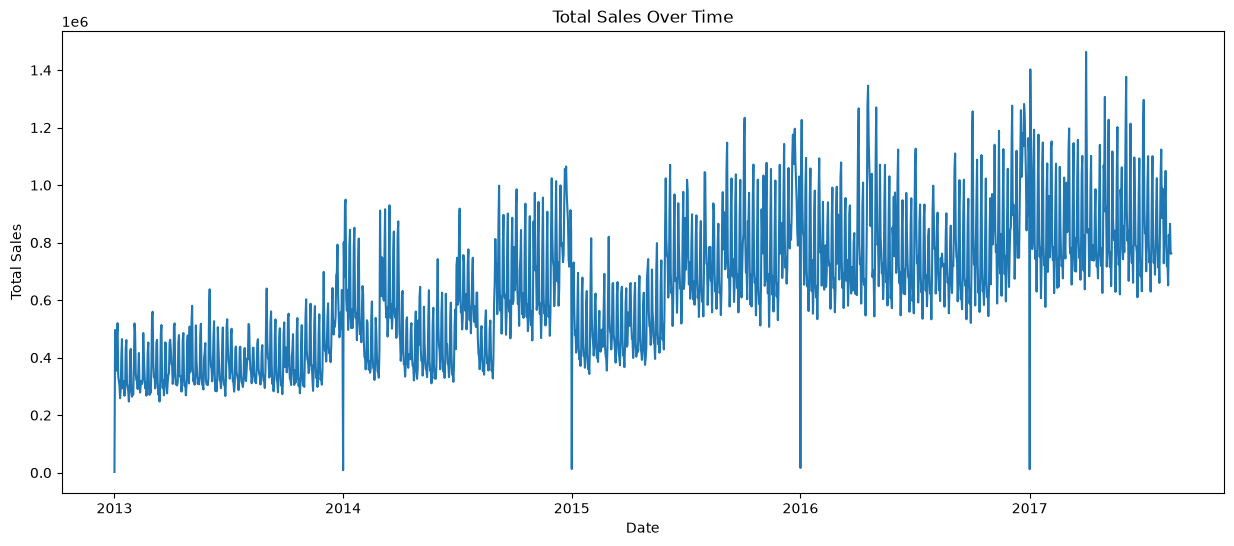

In [ ]:
import matplotlib.pyplot as plt
daily_sales = df.groupby("date")["sales"].sum()
plt.figure(figsize=(15,6))
plt.plot(daily_sales.index, daily_sales.values)
# Add title and labels
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
# Show the graph
plt.show()

In [9]:
# Convert date column to datetime

df["date"] = pd.to_datetime(df["date"])

# Create new features

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["dayofweek"] = df["date"].dt.dayofweek

print(df.head())

   id       date  store_nbr      family  sales  onpromotion  year  month  day  \
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0  2013      1    1   
1   1 2013-01-01          1   BABY CARE    0.0            0  2013      1    1   
2   2 2013-01-01          1      BEAUTY    0.0            0  2013      1    1   
3   3 2013-01-01          1   BEVERAGES    0.0            0  2013      1    1   
4   4 2013-01-01          1       BOOKS    0.0            0  2013      1    1   

   dayofweek  
0          1  
1          1  
2          1  
3          1  
4          1  


In [10]:
monthly_sales = df.groupby("month")["sales"].mean()

print(monthly_sales)

month
1     341.921554
2     320.928869
3     352.009294
4     339.199841
5     341.765820
6     353.597842
7     374.219111
8     336.992535
9     362.297418
10    362.407132
11    375.681762
12    453.740370
Name: sales, dtype: float64


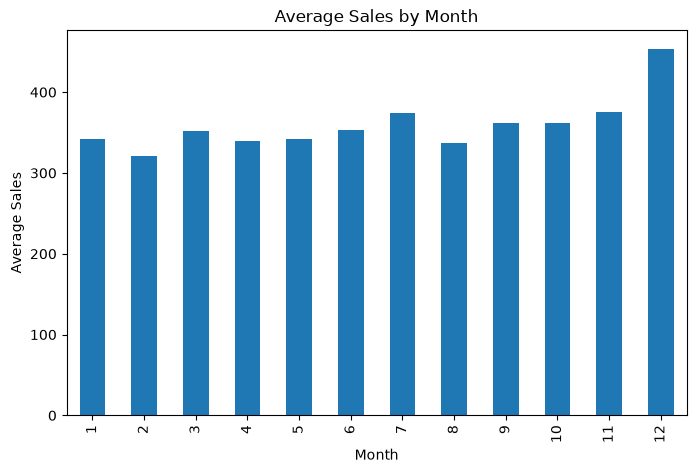

In [11]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="bar", figsize=(8,5))

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

In [12]:
from sklearn.model_selection import train_test_split

# Input features (X)
X = df[["store_nbr", "onpromotion", "year", "month", "day", "dayofweek"]]

# Target (y)
y = df["sales"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2400710, 6)
Testing data: (600178, 6)


In [13]:
from sklearn.ensemble import RandomForestRegressor

# Create the model
model = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [14]:
# Predict sales
y_pred = model.predict(X_test)

# Show first 10 predictions
print(y_pred[:10])

[6062.06          0.          879.97114286   52.39372343    0.
  100.49319668 1108.8063391    48.17553228   48.63885753   37.45890825]


In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate accuracy
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("R² Score:", r2)

Mean Absolute Error (MAE): 324.26840620157344
R² Score: 0.4709687737568252


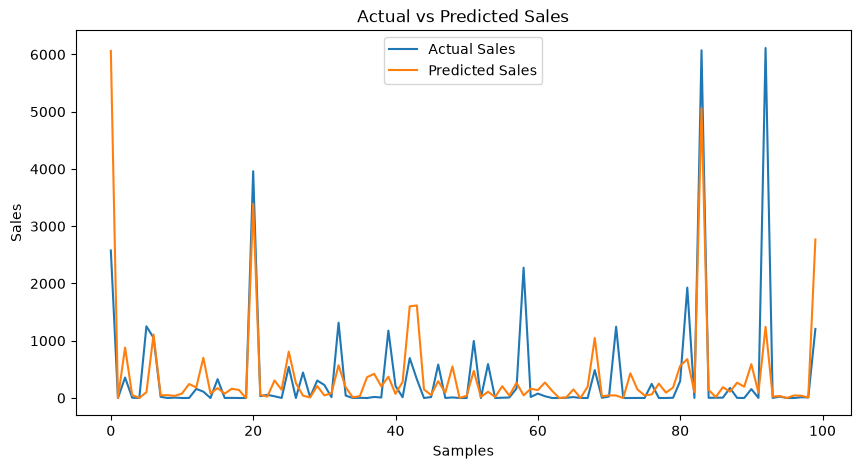

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual Sales")
plt.plot(y_pred[:100], label="Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.xlabel("Samples")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [17]:
import pandas as pd

results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

results.head()

,Actual Sales,Predicted Sales
0,2576.000,6062.060000
1,0.000,0.000000
2,357.354,879.971143
3,5.000,52.393723
4,0.000,0.000000


In [18]:
results.to_csv("../reports/predictions.csv", index=False)

print("Predictions saved successfully!")

Predictions saved successfully!


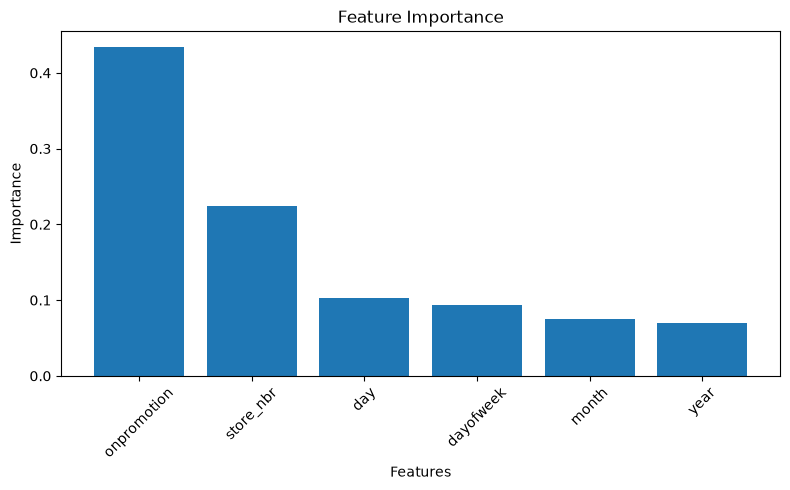

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
import joblib

joblib.dump(model, "../models/sales_forecasting_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [21]:
results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

results.to_csv("../reports/predictions.csv", index=False)

print(results.head())

   Actual Sales  Predicted Sales
0      2576.000      6062.060000
1         0.000         0.000000
2       357.354       879.971143
3         5.000        52.393723
4         0.000         0.000000
